# 9. Cosmological Simulations

RAMSES writes the *same* info-file fields for every run, so Mera reads them for
both idealised and cosmological simulations. A **non-cosmological** run carries
sentinel values (`aexp = 1`, `H0 = 1`, `omega_m = 1`, `omega_l = 0`); a
**cosmological** run carries physical values (e.g. `aexp = 0.875`, `H0 = 70.3`,
`omega_m = 0.276`, `omega_l = 0.724`).

This tutorial shows the cosmology-aware tools Mera builds on top of that:

- detect a cosmological run and get its redshift / full cosmological state
- `gettime` returning the **age of the universe** (cosmological `info.time` is
  conformal time, not proper time)
- **stellar ages**, **formation redshift** and **formation time** from the
  particle birth times (RAMSES stores these as conformal time)
- the gas **overdensity** field
- **comoving ↔ proper** conversions

All of these are *derived* from fields that have always existed on `InfoType`, so
they also work on `MERA` files of any age (see *Backward compatibility* below).

## Test simulation and reference

The example below uses the public **yt project sample** output `output_00080`
— a cosmological zoom simulation (gas, dark matter and stars), provided by the
yt project (Turk et al. 2011, *yt: A Multi-code Analysis Toolkit for
Astrophysical Simulation Data*, ApJS 192, 9). It is **not**
redistributed with Mera; download it once with:

```bash
mkdir -p yt_cosmo && cd yt_cosmo
curl -OL https://yt-project.org/data/output_00080.tar.gz
tar xzf output_00080.tar.gz
```

Snapshot properties: `z ≈ 0.143` (`aexp ≈ 0.875`), `H0 = 70.3`, `Ωm = 0.276`,
`ΩΛ = 0.724`, flat (`Ωk = 0`).

## Reading a cosmological run

`getinfo` automatically detects a cosmological run and prints a dedicated
cosmology block (redshift, scale factor, density parameters, age, lookback and
Hubble time). The reported *simulation time* is the **age of the universe** at
the snapshot, not the raw conformal `info.time`.

In [1]:
using Mera
info = getinfo(80, "/Volumes/FASTStorage/Simulations/Mera-Tests/RAMSES/yt_cosmo");

[Mera]: 2026-06-01T19:55:47.873



Code: RAMSES
output [80] summary:


mtime: 2012-08-13T16:51:06
ctime: 2026-06-01T07:42:48.561
simulation time: 11.925 [Gyr] (age of universe)
boxlen: 62.14 [Mpc]
ncpu: 16
ndim: 3
-------------------------------------------------------
cosmological:  true
redshift z:    0.1426   (aexp = 0.8752)
H0: 70.30 km/s/Mpc   Ωm: 0.276   ΩΛ: 0.724   Ωk: 0.000   Ωb: 0.045


age: 11.925 Gyr   lookback: 1.798 Gyr   Hubble time: 13.909 Gyr
-------------------------------------------------------
amr:           true
level(s): 6 - 16 --> cellsize(s): 970.86 [kpc] - 948.11 [pc]
-------------------------------------------------------
hydro:         true
hydro-variables:  6

  --> (:rho, :vx, :vy, :vz, :p, :var6)
γ: 1.4
-------------------------------------------------------
gravity:       true
gravity-variables: (:epot, :ax, :ay, :az)
-------------------------------------------------------
particles:     true  (no particle header file) 
particle-variables: 5  --> (:vx, :vy, :vz, :mass, :birth)
-------------------------------------------------------
rt:            false
clumps:           false
namelist-file:    false
timer-file:       false
compilation-file: false
makefile:         false
patchfile:        false



## Detecting a cosmological run

`iscosmological` returns `true`/`false`; `redshift` returns `z = 1/aexp − 1`
(`0` for a non-cosmological run).

In [2]:
iscosmological(info), redshift(info)

(true, 0.14255728632206321)

## Full cosmological state: `cosmology`

`cosmology(info)` returns a `NamedTuple` with the complete state of the snapshot
— redshift, scale factor, the density parameters, and derived quantities:
Hubble time, age of the universe, lookback time and the critical density
`ρ_crit = 3H(z)²/8πG`. Everything is computed from the stored info fields.

In [3]:
c = cosmology(info)

(iscosmological = true, redshift = 0.14255728632206321, aexp = 0.875229637910795, H0 = 70.3000030517578, omega_m = 0.276000022888184, omega_l = 0.723999977111816, omega_k = 0.0, omega_b = 0.0450000017881393, hubble_time_Gyr = 13.9088503437748, age_Gyr = 11.92526533595642, lookback_Gyr = 1.7984823184196177, rho_crit_cgs = 1.0542295486333991e-29)

## Cosmic time with `gettime`

In a cosmological run `info.time` is **conformal** time (negative), so the naive
`info.time × scale` is meaningless. `gettime` therefore returns the **age of the
universe** at the snapshot, in the requested unit.

In [4]:
gettime(info, :Gyr)    # age of the universe at this snapshot [Gyr]

11.92526533595642

## Mean and critical densities

`mean_matter_density` and `mean_baryon_density` give the mean (proper) densities
at the snapshot redshift, `ρ̄ = Ω · ρ_crit,0 · (1+z)³` — the reference densities
for overdensities. The critical density at the snapshot is `c.rho_crit_cgs`.

In [5]:
mean_matter_density(info), mean_baryon_density(info), c.rho_crit_cgs   # [g/cm³]

(3.821451389512857e-30, 6.230626996398271e-31, 1.0542295486333991e-29)

## Stellar ages

RAMSES stores a star particle's **birth time as conformal (super-conformal)
time**, the same variable as `info.time`. A physical age therefore is *not*
`(info.time − birth) × scale`; it is the difference of proper cosmic times at
the snapshot and at birth. Mera does this conversion via a Friedmann
integration table (as in RAMSES' own `friedman` routine), so `getvar(…, :age)`
returns the correct physical age on a cosmological run.

Star particles have `birth < 0`; non-star particles (dark matter) carry the
sentinel `birth = 0` and are reported with age `0` — select stars with
`birth .< 0`.

In [6]:
particles = getparticles(info);
birth = getvar(particles, :birth)
stars = birth .< 0.0
ages  = getvar(particles, :age, :Gyr)
(n_stars = count(stars), age_min = minimum(ages[stars]), age_max = maximum(ages[stars]))

[Mera]: Get particle data: 2026-06-01T19:55:52.461



Using threaded processing with 4 threads
Key vars=(:level, :x, :y, :z, :id)
Using var(s)=(1, 2, 3, 4, 5) = (:vx, :vy, :vz, :mass, :birth) 



domain:


xmin::xmax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 62.135 [Mpc]
ymin::ymax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 62.135 [Mpc]
zmin::zmax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 62.135 [Mpc]

Processing 16 CPU files using 4 threads
Mode: Threaded processing


Combining results from 4 thread(s)...
Found 1.090895e+06 particles
Memory used for data table :

74.9068775177002 MB
-------------------------------------------------------



(n_stars = 31990, age_min = 5.0186259167604e-15, age_max = 11.225102965242586)

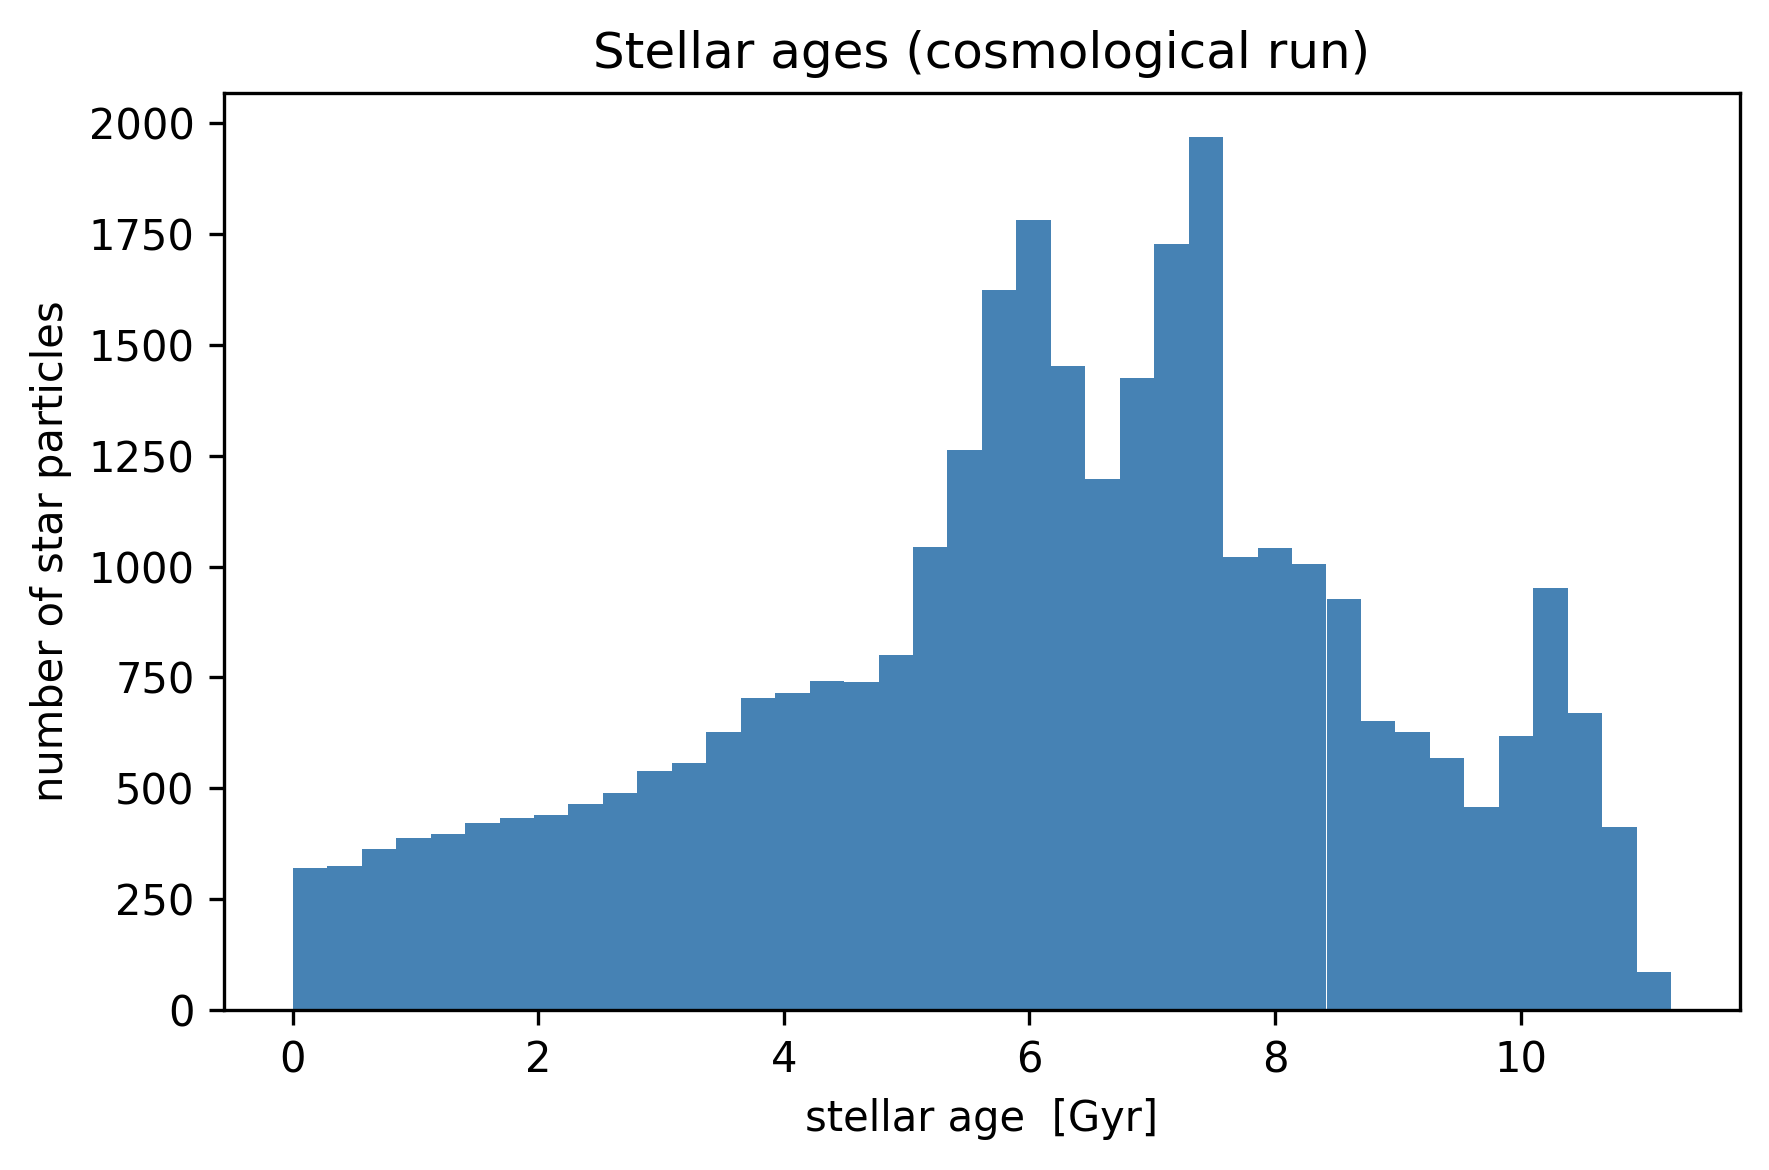

In [7]:
using PyPlot
rc("figure", dpi=300); rc("savefig", dpi=300)
figure(figsize=(6,4))
hist(ages[stars], bins=40, color="steelblue")
xlabel("stellar age  [Gyr]"); ylabel("number of star particles")
title("Stellar ages (cosmological run)"); tight_layout();


## Formation redshift and formation time

`:zform` (alias `:formation_redshift`) gives the redshift at which each star
formed, `:formation_time` the corresponding age of the universe. They satisfy
`formation_time + age = age of the universe at the snapshot`.

**Non-star particles (`birth ≥ 0`) return `NaN`** for both `:zform` and
`:formation_time` (the underlying `formation_redshift` / `formation_time` are
undefined for the `birth = 0` sentinel) — so select stars with `birth .< 0` or
filter `!isnan`, **not** `== 0`. (Only `:age` returns `0` for non-stars.)

In [8]:
zform = getvar(particles, :zform)
ftime = getvar(particles, :formation_time, :Gyr)
(zform_max = maximum(zform[stars]), ftime_min = minimum(ftime[stars]), ftime_max = maximum(ftime[stars]))

(zform_max = 7.593387894486433, ftime_min = 0.7001634695003264, ftime_max = 11.925247959877392)

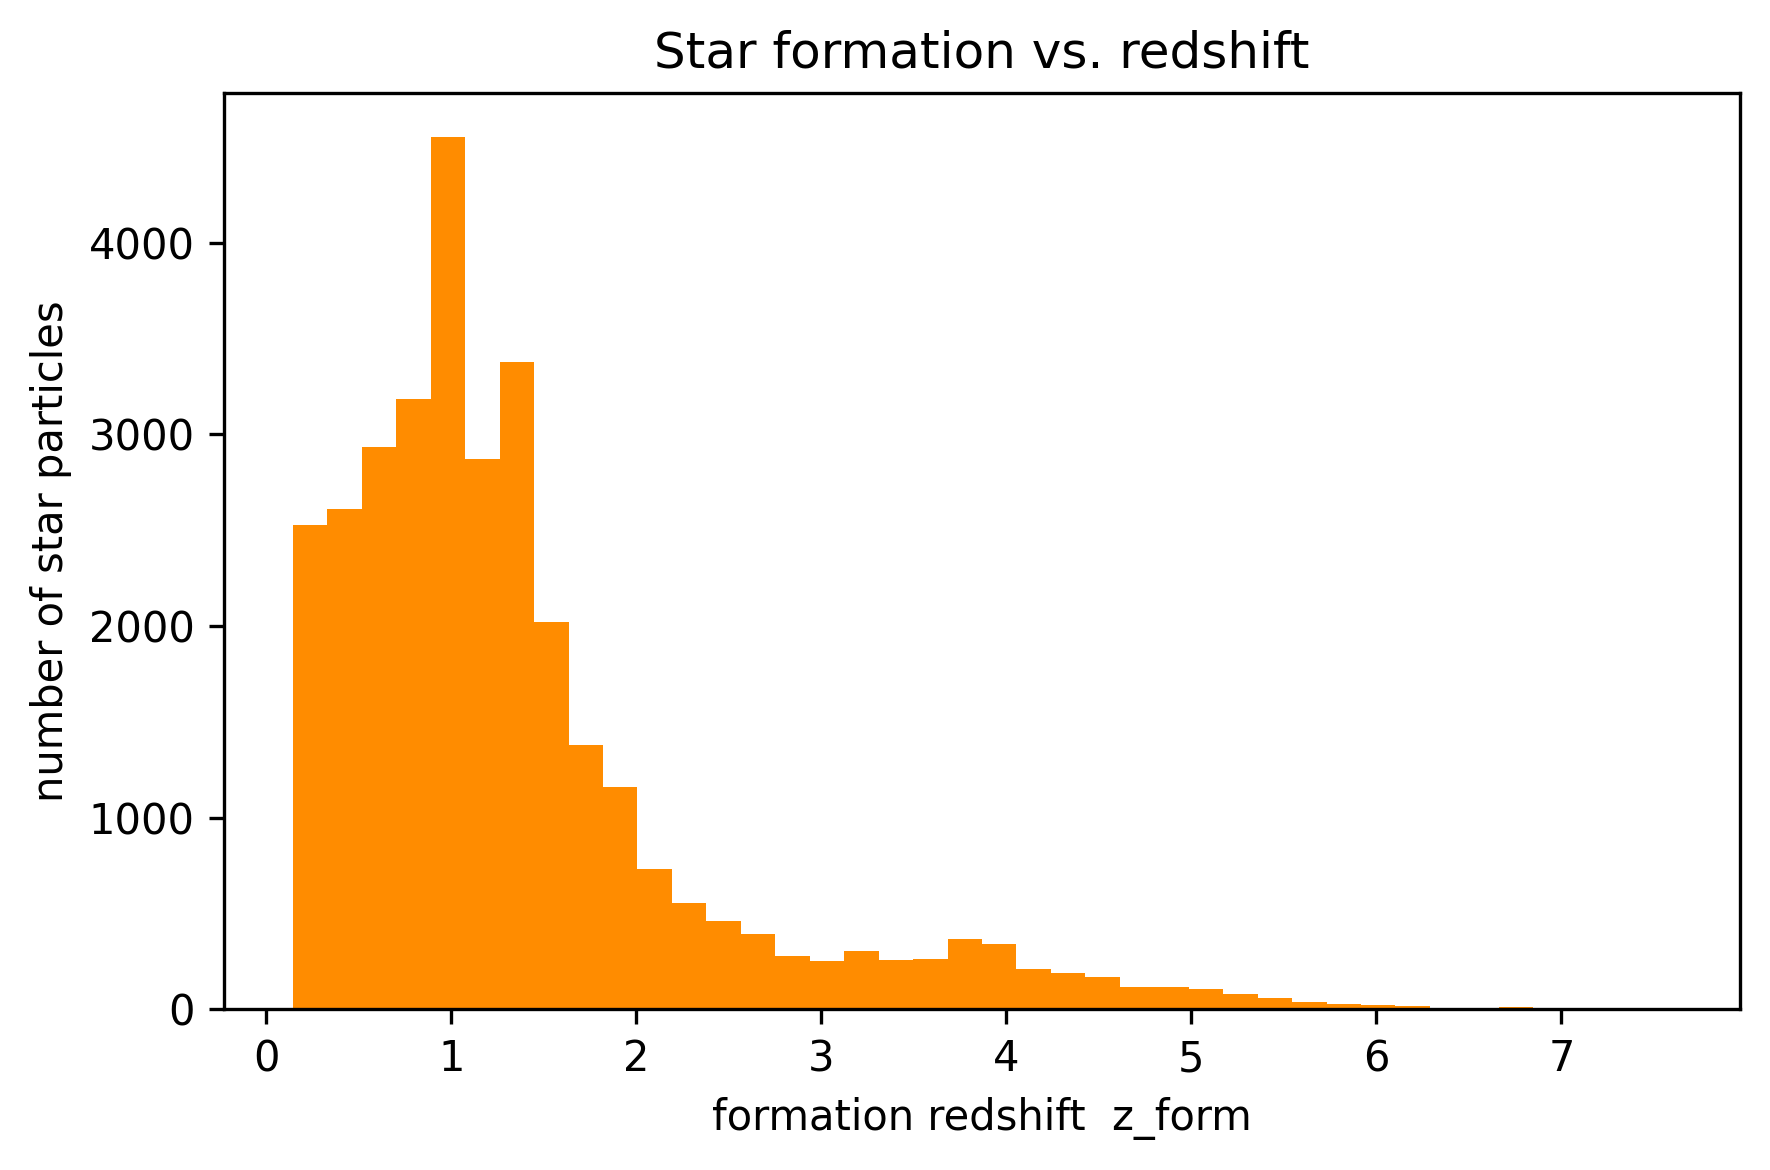

In [9]:
figure(figsize=(6,4))
hist(zform[stars], bins=40, color="darkorange")
xlabel("formation redshift  z_form"); ylabel("number of star particles")
title("Star formation vs. redshift"); tight_layout();


## Gas overdensity

`:overdensity` (alias `:delta`) is the gas density contrast relative to the
mean baryon density, `δ = ρ/ρ̄_b − 1`. By construction `δ ≥ −1`; it is ≈ 0 in
the mean field and ≫ 1 in collapsed structures.

In [10]:
gas = gethydro(info);
delta = getvar(gas, :overdensity)
(delta_min = minimum(delta), delta_max = maximum(delta))

[Mera]: Get hydro data: 2026-06-01T19:56:00.568



Key vars=(:level, :cx, :cy, :cz)


Using var(s)=(1, 2, 3, 4, 5, 6) = (:rho, :vx, :vy, :vz, :p, :var6) 

domain:
xmin::xmax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 62.135 [Mpc]
ymin::ymax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 62.135 [Mpc]
zmin::zmax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 62.135 [Mpc]

📊 Processing Configuration:


   Total CPU files available: 16
   Files to be processed: 16
   Compute threads: 4
   GC threads: 4



Processing files:   0%|                                                  |  ETA: N/A (  N/A  s/it)

...

Final data size: 1749455 cells, 6 variables
Creating Table from 1749455 cells with max 4 threads...


  Threading: 4 threads for 10 columns


  Max threads requested: 4
  Available threads: 4
  Using parallel processing with 4 threads
  Creating IndexedTable with 10 columns...
  0.846090 seconds (3.28 M allocations: 478.784 MiB, 0.80% gc time, 88.93% compilation time: 1% of which was recompilation)
✓ Table created in 1.142 seconds


Memory used for data table :133.47387886047363 MB
-------------------------------------------------------



(delta_min = -0.9852022034691776, delta_max = 1.2811226613578297e7)

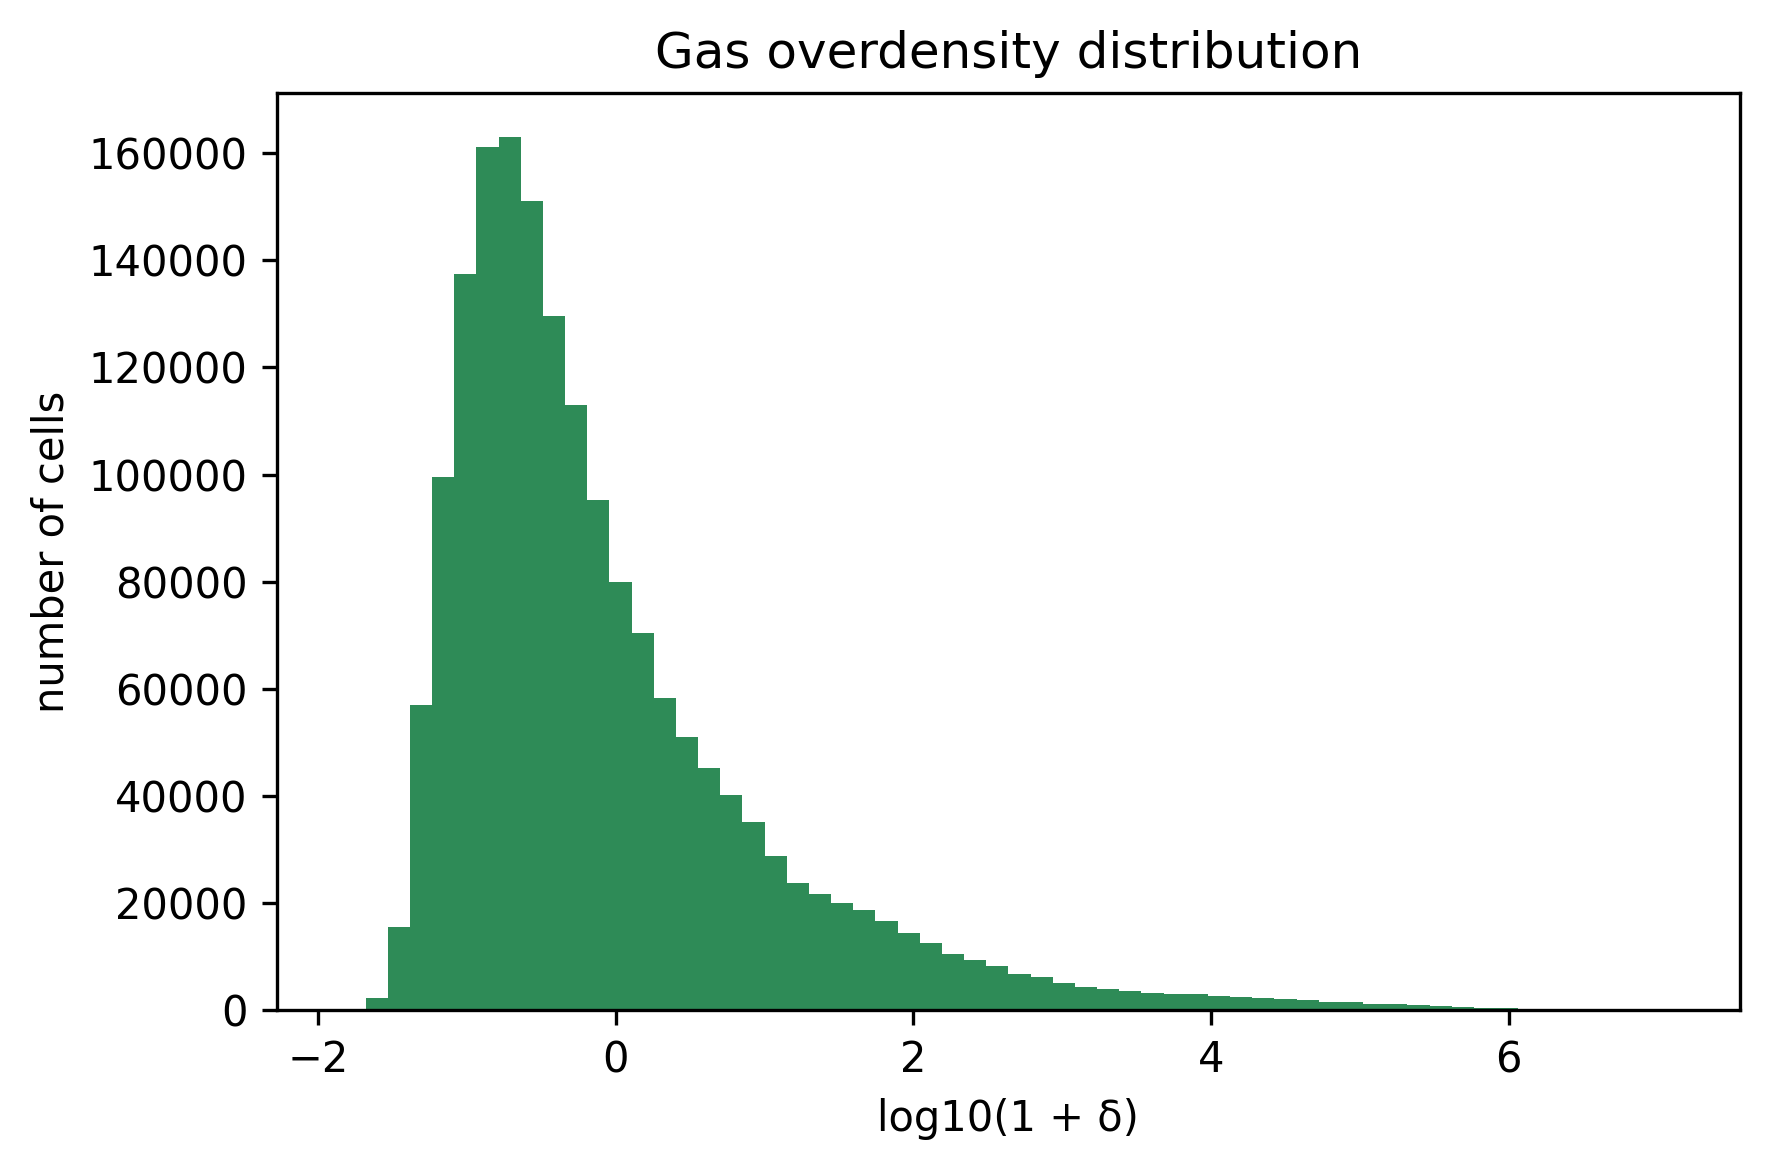

In [11]:
figure(figsize=(6,4))
hist(log10.(1.0 .+ delta), bins=60, color="seagreen")
xlabel("log10(1 + δ)"); ylabel("number of cells")
title("Gas overdensity distribution"); tight_layout();


## Comoving ↔ proper

RAMSES `unit_l`/`unit_d` (hence all of Mera's length/density scales) are the
**proper (physical)** values at the snapshot's scale factor, so positions,
densities, projections and surface densities returned by Mera are in the proper
frame. Convert to/from comoving with the helpers (identities for a
non-cosmological run, where `aexp = 1`):

In [12]:
l_proper   = comoving_to_proper_length(info, 1.0)    # comoving → proper  (× aexp)
l_comoving = proper_to_comoving_length(info, 1.0)    # proper → comoving  (÷ aexp)
ρ_proper   = comoving_to_proper_density(info, 1.0)   # × aexp⁻³
(l_proper, l_comoving, ρ_proper)

(0.875229637910795, 1.1425572863220632, 1.4915367304559788)

## Backward compatibility

None of this required new stored fields: the accessors read only `aexp`, `H0`
and the `omega_*` parameters, which every `InfoType` — and therefore every
`MERA` file ever written — already contains. Consequently:

- old `MERA`/JLD2 files load unchanged, and `infodata` prints the same cosmology
  block as `getinfo`;
- on a non-cosmological run `iscosmological` is `false`, `redshift` is `0`, and
  the cosmology-only `getvar` variables (`:zform`, `:formation_time`,
  `:overdensity`) raise a clear error.

### Summary of the cosmology API

| call | returns |
|------|---------|
| `iscosmological(info)` | `Bool` |
| `redshift(info)` | `z = 1/aexp − 1` |
| `cosmology(info)` | NamedTuple (z, aexp, H0, Ω's, age, lookback, Hubble time, ρ_crit) |
| `gettime(info, :Gyr)` | age of the universe at the snapshot |
| `getvar(particles, :age)` | physical stellar age |
| `getvar(particles, :zform)` | formation redshift |
| `getvar(particles, :formation_time)` | formation time (age of universe) |
| `getvar(hydro, :overdensity)` | gas overdensity `ρ/ρ̄_b − 1` |
| `mean_matter_density`, `mean_baryon_density` | mean proper densities at z |
| `comoving_to_proper_*`, `proper_to_comoving_*` | frame conversion |